In [1]:
import torch 
import torch.fft as fft
import torch.nn as nn
import numpy as np
import h5py
import math
import json
import train
import train_mri_recon 
import os
import gc
import matplotlib.pyplot as plt

from mri_utils import mri_encoding, mri_decoding, walsh_smaps, fftc, ifftc, make_acc_mask, quant_complex, quant_tensor, espirit, mri_awgn
from functorch import jacrev, jacfwd
from solvers import conj_grad
from pprint import pprint
from functools import partial
from utils import saveimg, load_data_knee, complex_polynomial_field
from model_utils import uball_project
from metrics import joint_normalize, psnr, ssim
from immap import ImMAP
from dds import DDS
from nle import whiten 

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
# Load ImMAP nets
organ = 'knee'
accel = '6'
device = 'cuda'
net = train.load_model('trained_nets/'+organ+'/LPDSNet/args.json', device = device)
# net_immap2p5 = load_model('configs/knee/immap2p5_R'+str(accel)+'_config.json', device = device)
net_immap2p5 = train_mri_recon.load_model('trained_nets/'+organ+'/LPDS_ImMAP2p5_R6_noSSDUMasking_sigmaScaleON_noiseCOSINE'+'/args.json', device = device)
# net_immap2p5 = train.load_model('trained_nets/'+organ+'/LPDS_ImMAP2p5_SSDU_R'+str(accel)+'_baseAccel1x_sigmaScaleON_noiseUNIFORM/args.json', device = device)
# lpdsnet_e2e = load_model('configs/knee/mri_R'+str(accel)+'_config.json', device = device)
lpdsnet_e2e = train.load_model('trained_nets/'+organ+'/LPDS_MRI_Recon_R'+str(accel)+'_nl1nl2Loss/args.json', device = device)

Initializing net from trained_nets/knee/LPDSNet/net.ckpt ...
Loading net state-dict...
Loading opt state-dict...
Loading sched state-dict...
Total Number of Parameters: 755,490
Using trained_nets/knee/LPDSNet ...
Initializing net from trained_nets/knee/LPDS_ImMAP2p5_R6_noSSDUMasking_sigmaScaleON_noiseCOSINE/net.ckpt ...
Loading net state-dict...
Loading opt state-dict...
Loading sched state-dict...
Current Learning Rate(s):
2.257040831817014e-05
Total Number of Parameters: 760,710
Using trained_nets/knee/LPDS_ImMAP2p5_R6_noSSDUMasking_sigmaScaleON_noiseCOSINE ...
Initializing net from trained_nets/knee/LPDS_MRI_Recon_R6_nl1nl2Loss/net.ckpt ...
Loading net state-dict...
Loading opt state-dict...
Loading sched state-dict...
Total Number of Parameters: 760,560
Using trained_nets/knee/LPDS_MRI_Recon_R6_nl1nl2Loss ...


In [5]:
# Load data sample
kspace, smaps, organ_mask, image = load_data_knee(slice = 25, kspace_root = "../../datasets/fastmri/knee/multicoil_val", device = device)

In [6]:
# Generate acceleration mask
Ny, Nx = image.shape[-2], image.shape[-1]
mask = make_acc_mask(
        shape=(Ny, Nx),
        accel=6,
        acs_lines=20
    ).to(image.device)

# plt.imshow(mask.detach().cpu()[0,0])

In [7]:
# Generate a sample 
M = complex_polynomial_field(
    smaps.shape,
    degree=5,
    temperature=0.5,
    centered=True
)

smaps_M = M * smaps

In [8]:
# Initialize ImMAP 
immap = ImMAP(net, lam = 2, beta = 0.05, sigma_L = 0.01)

In [9]:
# Generate simulated kspace
sim_kspace, _ = mri_awgn(image, mask, smaps_M, 0.00)
meas_kspace = mask*kspace

In [10]:
# Plot
def plot_img(tensor):
    plt.imshow(torch.squeeze(tensor).abs().detach().cpu(), cmap = 'gray')

In [11]:
# Whiten smaps
x_w, smaps_w, Sigma, zinv = whiten(ifftc(meas_kspace), smaps, mask = mask)
# From whitened image domain data and smaps, create corresponding whitened kspace
kspace_w = fftc(x_w)

In [22]:
# Try ImMAP2 with modified smaps
immap.beta = 0.1
out = immap.forward_2p5(
    mask*kspace, Sigma.max(), mask, smaps,
    save_dir = None, verbose=True
)

Iteration 1 complete. Noise level: 0.9981193542480469. p_t: 0.00016638099623378366 Tolerance Reached: True
Iteration 2 complete. Noise level: 0.9970834851264954. p_t: 0.00016655428044032305 Tolerance Reached: True
Iteration 3 complete. Noise level: 0.9952529668807983. p_t: 0.0001668617915129289 Tolerance Reached: True
Iteration 4 complete. Noise level: 0.9923887252807617. p_t: 0.00016734637029003352 Tolerance Reached: True
Iteration 5 complete. Noise level: 0.988624095916748. p_t: 0.00016798971046227962 Tolerance Reached: True
Iteration 6 complete. Noise level: 0.9839857220649719. p_t: 0.0001687925250735134 Tolerance Reached: True
Iteration 7 complete. Noise level: 0.9788495302200317. p_t: 0.0001696948747849092 Tolerance Reached: True
Iteration 8 complete. Noise level: 0.9734395742416382. p_t: 0.00017066080181393772 Tolerance Reached: True
Iteration 9 complete. Noise level: 0.9677456617355347. p_t: 0.0001716949773253873 Tolerance Reached: True
Iteration 10 complete. Noise level: 0.9605

In [23]:
# Revise sensitivity profile
out = zinv*out

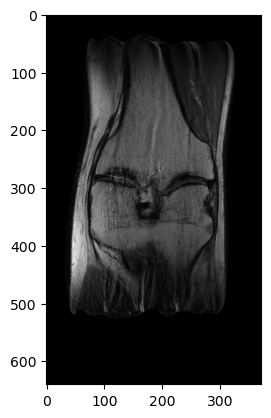

In [24]:
plot_img(out)

In [17]:
_, out, _ = immap.forward_2p5(
    meas_kspace, Sigma.max(), mask, smaps,
    net_immap2p5, torch.squeeze(organ_mask), save_dir=None, verbose=True, mode=1,
    ssdu_masking = False,
    ssdu_base_accel = 1,
    ssdu_rho = (0.1, 0.2),
    acs_lines = 20,
)

Iteration 1 complete. Noise level: 1.0428560972213745.
Iteration 2 complete. Noise level: 1.0434985160827637.
Iteration 3 complete. Noise level: 1.043148398399353.
Iteration 4 complete. Noise level: 1.0411039590835571.
Iteration 5 complete. Noise level: 1.0402354001998901.
Iteration 6 complete. Noise level: 1.0376477241516113.
Iteration 7 complete. Noise level: 1.0349446535110474.
Iteration 8 complete. Noise level: 1.0318560600280762.
Iteration 9 complete. Noise level: 1.0282702445983887.
Iteration 10 complete. Noise level: 1.022405982017517.
Iteration 11 complete. Noise level: 1.0178062915802002.
Iteration 12 complete. Noise level: 1.0124247074127197.
Iteration 13 complete. Noise level: 1.007485032081604.
Iteration 14 complete. Noise level: 1.0018104314804077.
Iteration 15 complete. Noise level: 0.9954436421394348.
Iteration 16 complete. Noise level: 0.988370954990387.
Iteration 17 complete. Noise level: 0.9807369709014893.
Iteration 18 complete. Noise level: 0.9732555150985718.
Itera

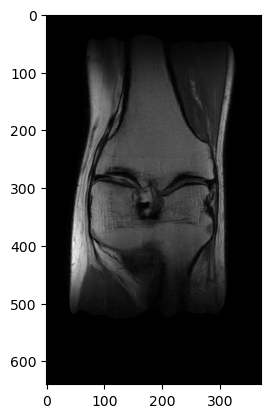

In [20]:
plot_img(out)

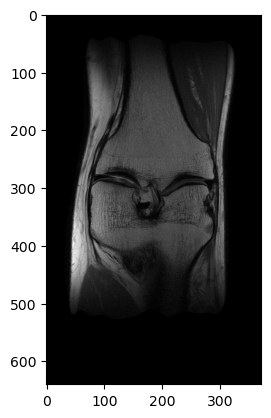

In [21]:
plot_img(image)